In [8]:
import numpy as np
import matplotlib.pyplot as plt

In [9]:

def plot_vectors_subplot(ax, vectors, colors, labels=None):
    """Helper function to plot vectors on a specific Matplotlib axis."""
    ax.axvline(x=0, color="lightgray", linestyle="--")
    ax.axhline(y=0, color="lightgray", linestyle="--")
    
    for i in range(len(vectors)):
        v = vectors[i]
        label = labels[i] if labels else None
        ax.quiver(0, 0, v[0], v[1], 
                  angles="xy", scale_units="xy", scale=1, 
                  color=colors[i], label=label)
        
    ax.set_xlim(-1, 5)
    ax.set_ylim(-1, 5)
    ax.set_aspect('equal')
    ax.grid(True, linestyle=':', alpha=0.6)
    if labels:
        ax.legend(loc='upper right')

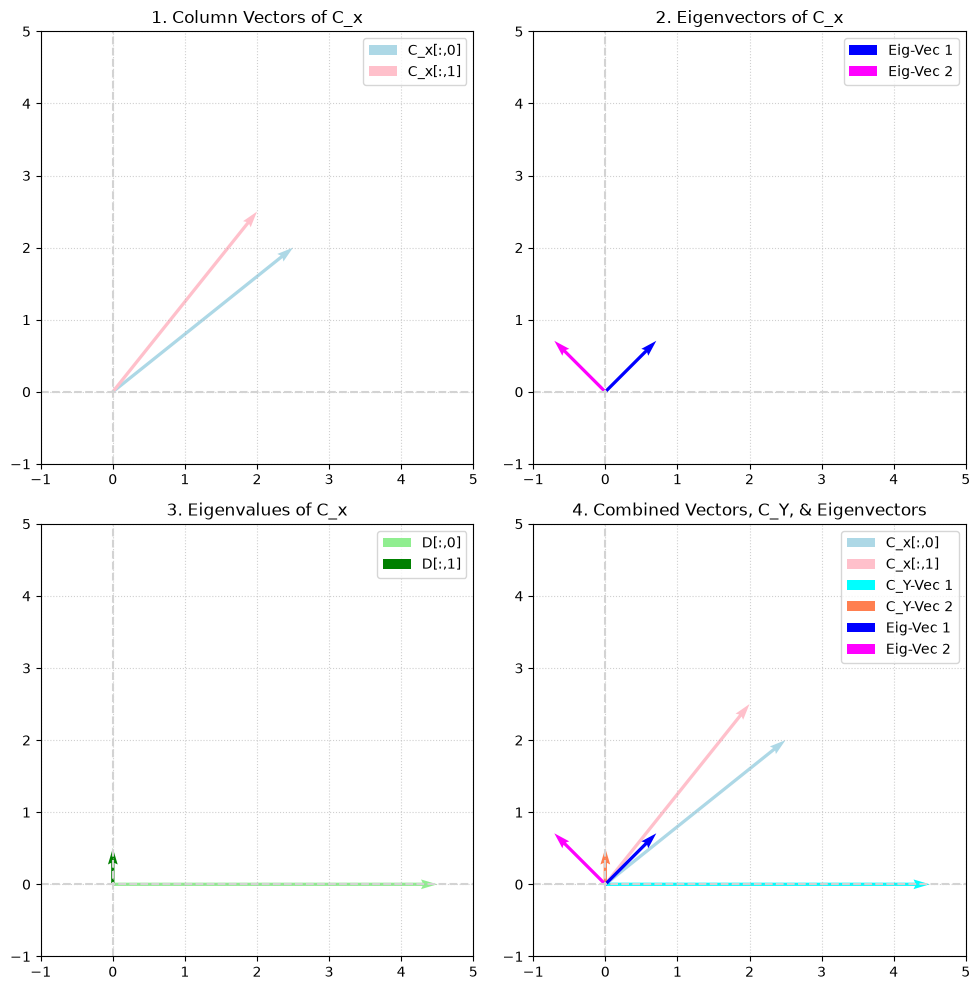

In [10]:
X = np.array([[1, -1, 2, -2], [2, -2, 1, -1]])
n = X.shape[1]
C_x = np.dot(X, X.T)/n
eigenvalues, eigenvectors = np.linalg.eig(C_x)
D = np.diag(eigenvalues)

# 4. Construct P (Rows as Principal Components)
P = eigenvectors.T
# 5. Compute Transformed Data Y = PX
Y = np.dot(P, X)

# 6. Verify C_Y is Diagonal
C_Y = (1/n)*np.dot(Y, Y.T) # We're not taking 1/n-1 (Bessel's Correction)

# Create a figure with 3 subplots
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

# Subplot 1: Column Vectors of B
plot_vectors_subplot(
    axes[0][0], 
    [C_x[:, 0], C_x[:, 1]], 
    ['lightblue', 'pink'], 
    labels=['C_x[:,0]', 'C_x[:,1]']
)
axes[0][0].set_title("1. Column Vectors of C_x")

# Subplot 2: Eigenvectors of B
plot_vectors_subplot(
    axes[0][1], 
    [eigenvectors[:, 0], eigenvectors[:, 1]], 
    ['blue', 'magenta'], 
    labels=['Eig-Vec 1', 'Eig-Vec 2']
)
axes[0][1].set_title("2. Eigenvectors of C_x")

# Subplot 3: Eigenvalue of C_x
plot_vectors_subplot(
    axes[1][0], 
    [D[:, 0], D[:, 1]], 
    ['lightgreen', 'green',], 
    labels=['D[:,0]', 'D[:,1]']
)
axes[1][0].set_title("3. Eigenvalues of C_x")

# Suplot 4: (Combined Vector, Eigenvectors, and CY is diagonal)

plot_vectors_subplot(
    axes[1][1], 
    [C_x[:, 0], C_x[:, 1], C_Y[:, 0], C_Y[:, 1], eigenvectors[:, 0], eigenvectors[:, 1]], 
    ['lightblue', 'pink', 'cyan', 'coral', 'blue', 'magenta'], 
    labels=['C_x[:,0]', 'C_x[:,1]', 'C_Y-Vec 1', "C_Y-Vec 2",'Eig-Vec 1', 'Eig-Vec 2']
)
axes[1][1].set_title("4. Combined Vectors, C_Y, & Eigenvectors")

plt.tight_layout()
plt.show()




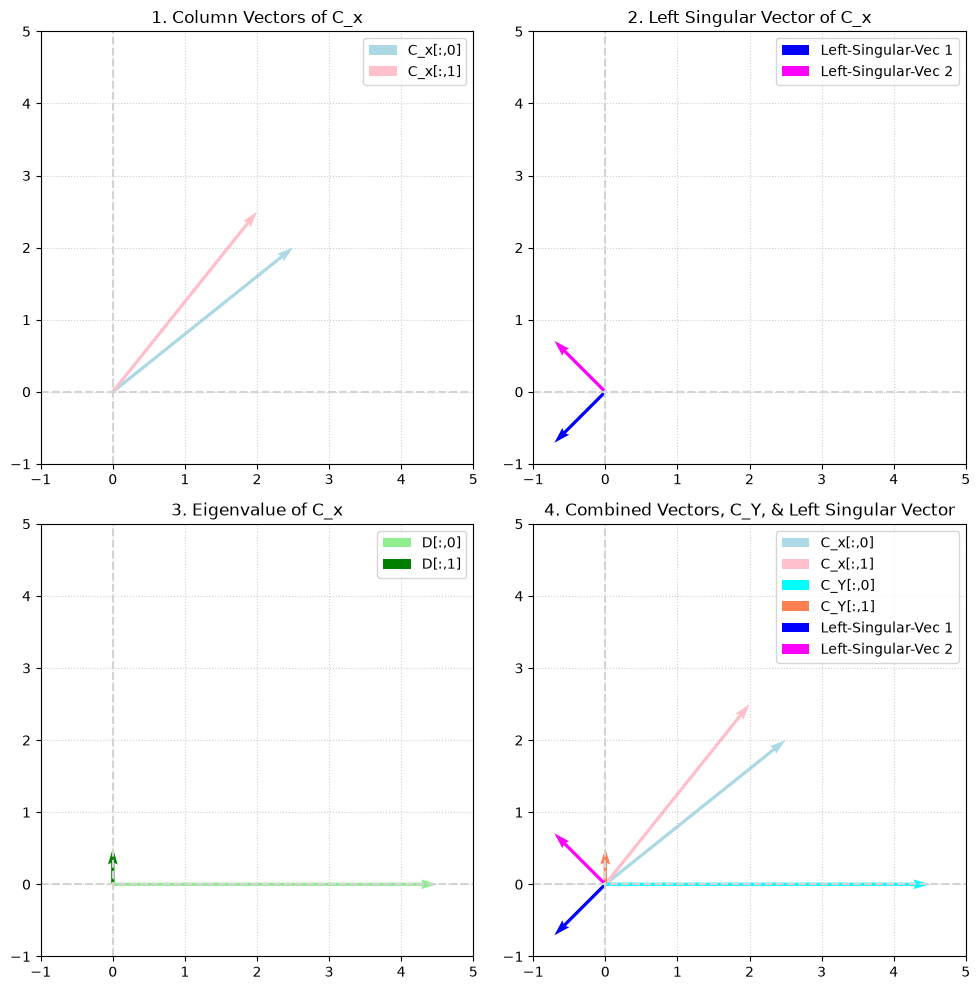

In [11]:
X = np.array([[1, -1, 2, -2], [2, -2, 1, -1]])
n = X.shape[1]
C_x = np.dot(X, X.T)/n
U, d, VT = np.linalg.svd(C_x)

# Create a figure with 3 subplots
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
U, d, VT = np.linalg.svd(C_x)
D = np.diag(d) 

# 4. Singular values
sigma_diag = np.sqrt(d*n)

# 5. Construct P (Rows as Principal Components)
P = U.T

# 6. Compute Transformed Data Y = PX
Y = np.dot(P, X)

# 7. Verify C_Y is Diagonal
C_Y = (1/n)*np.dot(Y, Y.T)

# Subplot 1: Column Vectors of B
plot_vectors_subplot(
    axes[0][0], 
    [C_x[:, 0], C_x[:, 1]], 
    ['lightblue', 'pink'], 
    labels=['C_x[:,0]', 'C_x[:,1]']
)
axes[0][0].set_title("1. Column Vectors of C_x")

# Subplot 2: Eigenvectors of B
plot_vectors_subplot(
    axes[0][1], 
    [U[:, 0], U[:, 1]], 
    ['blue', 'magenta'], 
    labels=['Left-Singular-Vec 1', 'Left-Singular-Vec 2']
)
axes[0][1].set_title("2. Left Singular Vector of C_x")

# Subplot 3: Eigenvalue of C_x
plot_vectors_subplot(
    axes[1][0], 
    [D[:, 0], D[:, 1]], 
    ['lightgreen', 'green'], 
    labels=['D[:,0]', 'D[:,1]']
)
axes[1][0].set_title("3. Eigenvalue of C_x")

# Subplot 4: Combined (Column Vectors, C_Y, & Left Singular Vector)
plot_vectors_subplot(
    axes[1][1], 
    [C_x[:, 0], C_x[:, 1], C_Y[:,0], C_Y[:,1], U[:, 0], U[:, 1]], 
    ['lightblue', 'pink','cyan', 'coral', 'blue', 'magenta'], 
    labels=['C_x[:,0]', 'C_x[:,1]', 'C_Y[:,0]', 'C_Y[:,1]','Left-Singular-Vec 1', 'Left-Singular-Vec 2']
)
axes[1][1].set_title("4. Combined Vectors, C_Y, & Left Singular Vector")

plt.tight_layout()
plt.show()




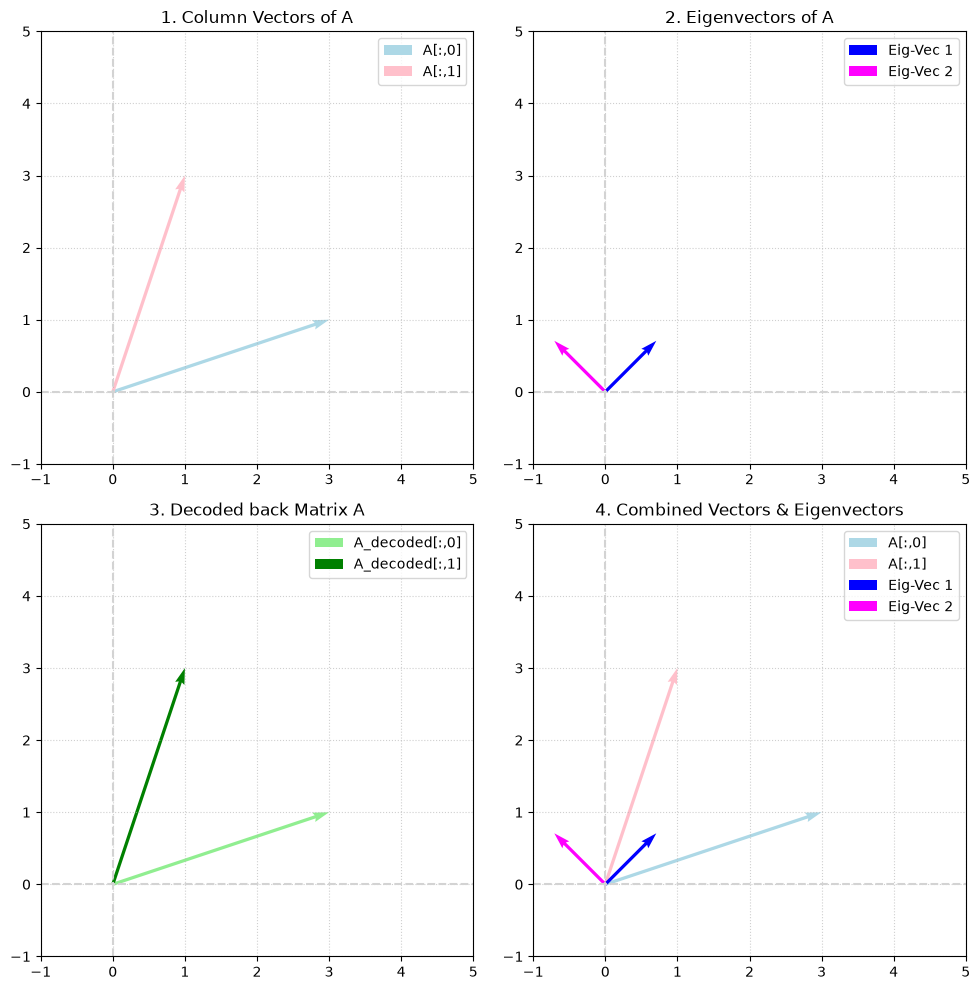

In [12]:
A = np.array([[3, 1], [1, 3]])
eigs = np.linalg.eig(A)
eig_vec = eigs.eigenvectors.real
eig_val = eigs.eigenvalues
# 3. Diagonalize the eigenvalues
D = np.diag(eig_val)
# 6. Because A's eigenvectors is orthogonal, it's inverse is simply it's eigenvector's transpose. 
# A is decoded # using A = Q\Lambda Q^{T}
A_decoded = np.dot(eig_vec, np.dot(D, eig_vec.T))


# Create a figure with 3 subplots
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

# Subplot 1: Column Vectors of B
plot_vectors_subplot(
    axes[0][0], 
    [A[:, 0], A[:, 1]], 
    ['lightblue', 'pink'], 
    labels=['A[:,0]', 'A[:,1]']
)
axes[0][0].set_title("1. Column Vectors of A")

# Subplot 2: Eigenvectors of B
plot_vectors_subplot(
    axes[0][1], 
    [eig_vec[:, 0], eig_vec[:, 1]], 
    ['blue', 'magenta'], 
    labels=['Eig-Vec 1', 'Eig-Vec 2']
)
axes[0][1].set_title("2. Eigenvectors of A")

# Subplot 3: Matrix A reconstruction
plot_vectors_subplot(
    axes[1][0], 
    [A[:, 0], A[:, 1]], 
    ['lightgreen', 'green'], 
    labels=['A_decoded[:,0]', 'A_decoded[:,1]']
)
axes[1][0].set_title("3. Decoded back Matrix A")

# Subplot 4: Combined (Column Vectors + Eigenvectors)
plot_vectors_subplot(
    axes[1][1], 
    [A[:, 0], A[:, 1], eig_vec[:, 0], eig_vec[:, 1]], 
    ['lightblue', 'pink', 'blue', 'magenta'], 
    labels=['A[:,0]', 'A[:,1]', 'Eig-Vec 1', 'Eig-Vec 2']
)
axes[1][1].set_title("4. Combined Vectors & Eigenvectors")

plt.tight_layout()
plt.show()

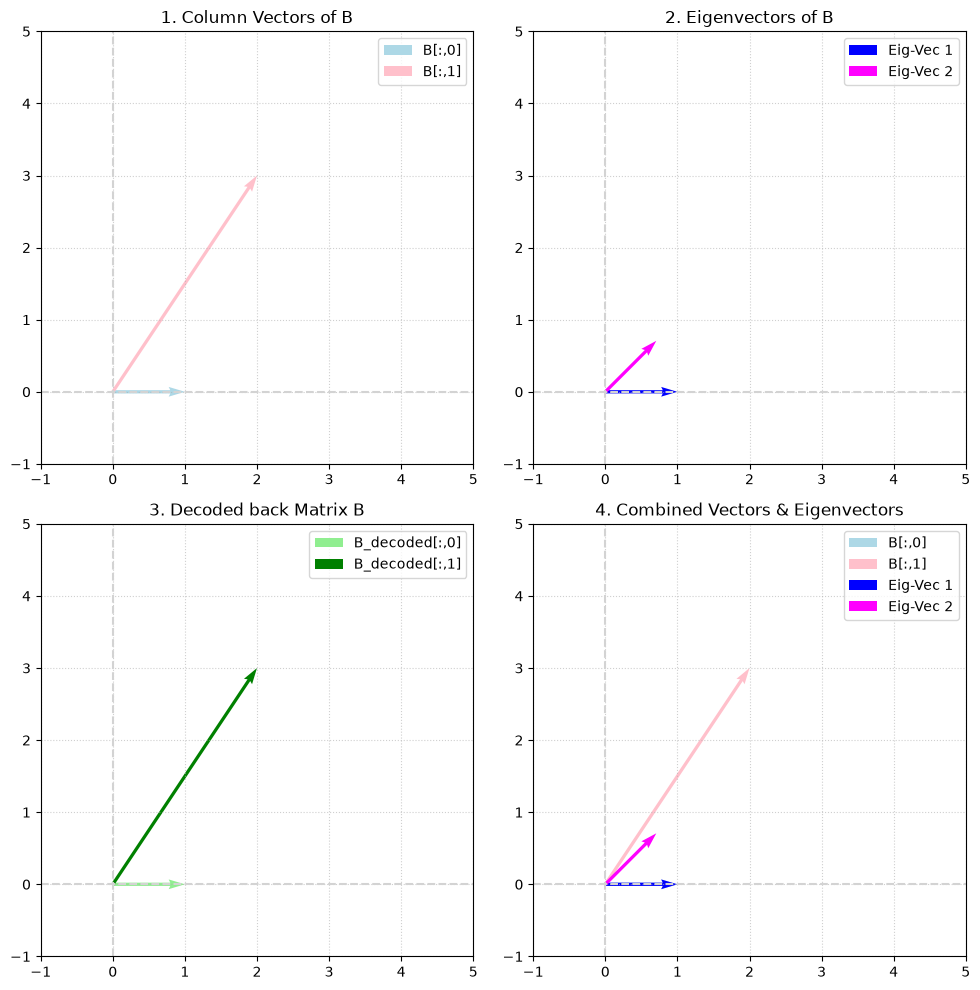

In [13]:
B = np.array([[1, 2], [0, 3]])
eigs = np.linalg.eig(B)
eig_vec = eigs.eigenvectors.real
eig_val = eigs.eigenvalues.real

# 3. Diagonalize the eigenvalues
D = np.diag(eig_val)

#6. Because B's eigenvectors is not orthogonal, we have to take its inverse.
# B is decoded using B = V\Lambda V^-1
V_inv = np.linalg.inv(eig_vec)

B_decoded = np.dot(eig_vec, np.dot(D, V_inv))

# Create a figure with 3 subplots
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

# Subplot 1: Column Vectors of B
plot_vectors_subplot(
    axes[0][0], 
    [B[:, 0], B[:, 1]], 
    ['lightblue', 'pink'], 
    labels=['B[:,0]', 'B[:,1]']
)
axes[0][0].set_title("1. Column Vectors of B")

# Subplot 2: Eigenvectors of B
plot_vectors_subplot(
    axes[0][1], 
    [eig_vec[:, 0], eig_vec[:, 1]], 
    ['blue', 'magenta'], 
    labels=['Eig-Vec 1', 'Eig-Vec 2']
)
axes[0][1].set_title("2. Eigenvectors of B")

# Subplot 3: Combined (Column Vectors + Eigenvectors)
plot_vectors_subplot(
    axes[1][0], 
    [B_decoded[:, 0], B_decoded[:, 1]], 
    ['lightgreen', 'green'], 
    labels=['B_decoded[:,0]', 'B_decoded[:,1]']
)
axes[1][0].set_title("3. Decoded back Matrix B")

# Subplot 4: Combined (Column Vectors + Eigenvectors)
plot_vectors_subplot(
    axes[1][1], 
    [B[:, 0], B[:, 1], eig_vec[:, 0], eig_vec[:, 1]], 
    ['lightblue', 'pink', 'blue', 'magenta'], 
    labels=['B[:,0]', 'B[:,1]', 'Eig-Vec 1', 'Eig-Vec 2']
)
axes[1][1].set_title("4. Combined Vectors & Eigenvectors")

plt.tight_layout()
plt.show()